<a href="https://colab.research.google.com/github/marinakamal1/undergrad_ml_assignments/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Marina Kamal

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

1. A model is linear when it is linear in its coefficients (parameters), not necessarily in the input variables. This means the model looks like a sum of coefficients multiplied by variables, such as:
beta1 * x1 + beta2 * x2. Even if you include transformed variables like x^2 or log(x), the model is still linear as long as the coefficients are not inside nonlinear functions or multiplied together.

2. A dummy variable (0 or 1) represents a comparison to a reference group (the group where the dummy = 0). The coefficient tells you how much the predicted outcome changes when moving from the reference group (0) to the group coded as 1, holding all other variables constant. The intercept represents the expected outcome for the reference group when all other variables are zero.

3. It can technically be used, but it is not appropriate. Linear regression predicts continuous values, so it can produce predictions less than 0 or greater than 1, which do not make sense as probabilities. It also does not model class boundaries well. That is why logistic regression is preferred for classification.

4. signs: Very high accuracy on training data but poor performance on test data, Large differences between training and testing error, Very large or unstable coefficient values, model is sensitive to small changes in the data

5. Multicollinearity happens when predictors are highly correlated, making it difficult to estimate their individual effects. In a two-stage approach: Stage 1: Regress one predictor on the others (or on instruments) to isolate the part of it that is not correlated
Stage 2: Use the predicted values from stage 1 in the main regression

This reduces shared variation and makes the coefficient estimates more stable.

6. Nonlinear relationships between y and x can be incorporated by including transformed versions of the predictors, such as squared or higher-order terms, logarithmic transformations, interaction terms, or splines. These approaches allow the model to capture more complex patterns while still remaining linear in its coefficients.

7. The slope coefficient represents the expected change in the outcome variable y for a one-unit increase in the predictor x, holding all other variables constant.

8. A train/test split involves dividing the data once into separate training and testing sets, making it simple and computationally efficient, but the results may depend heavily on how the data is split. In contrast, k-fold cross validation divides the data into k subsets and repeatedly trains and tests the model k times, each time using a different subset as the test set, which provides a more reliable estimate of model performance.

9. The value of k in k-fold cross validation is typically chosen as 5 or 10, as these values provide a good balance between computational efficiency and reliable performance estimates, with smaller k being faster but less stable and larger k being more accurate but more computationally intensive.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [4]:
import pandas as pd

df = pd.read_csv("Q1_clean.csv")

df = df.rename(columns={
    "Review Scores Rating": "Review_Scores_Rating",
    "Neighbourhood ": "Neighbourhood"
})

df = df[["Price", "Review_Scores_Rating", "Neighbourhood"]].dropna()

avg_table = df.groupby("Neighbourhood")[["Price", "Review_Scores_Rating"]].mean()
print(avg_table)

                    Price  Review_Scores_Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


Manhattan is the most expensive borough on average, since it has the highest mean nightly price at about 183.66.

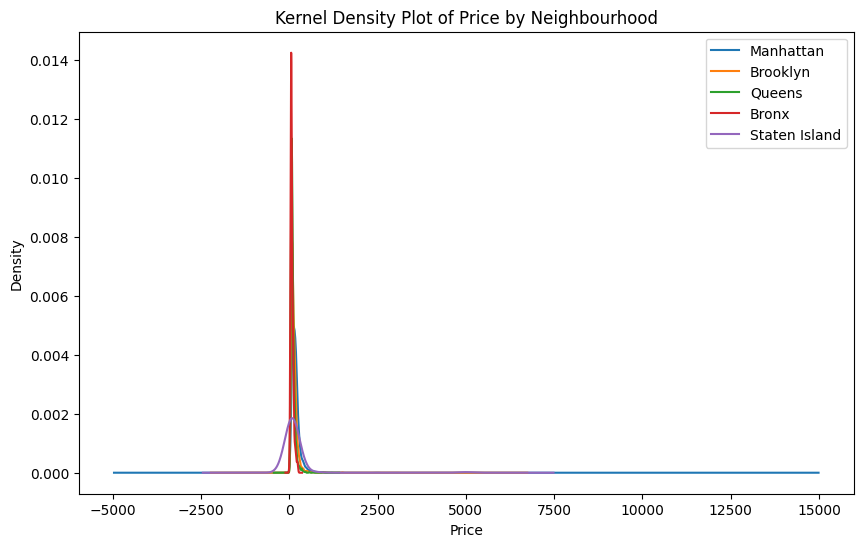

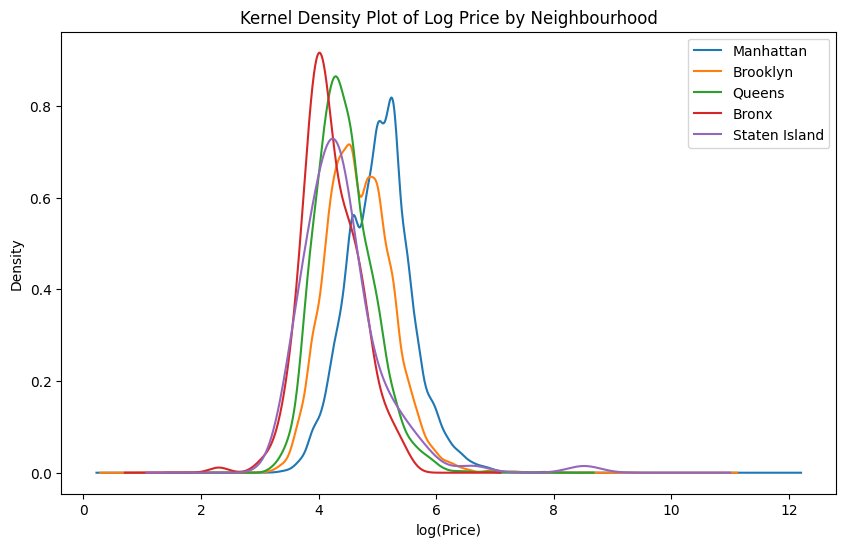

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for b in df["Neighbourhood"].unique():
    df.loc[df["Neighbourhood"] == b, "Price"].plot(kind="density", label=b)
plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.xlabel("Price")
plt.legend()
plt.show()

df["log_price"] = np.log(df["Price"])

plt.figure(figsize=(10,6))
for b in df["Neighbourhood"].unique():
    df.loc[df["Neighbourhood"] == b, "log_price"].plot(kind="density", label=b)
plt.title("Kernel Density Plot of Log Price by Neighbourhood")
plt.xlabel("log(Price)")
plt.legend()
plt.show()

From the kernel density plot of log(price), the distributions across boroughs become much more compressed and easier to compare than in the raw price scale. All boroughs now appear more approximately symmetric, indicating that the log transformation reduces the strong right skew seen in price.Manhattan is clearly shifted to the right relative to the other boroughs, which indicates that it has consistently higher prices even after taking the log. Brooklyn and Queens are somewhat in the middle, with their distributions overlapping but centered slightly lower than Manhattan. The Bronx has the left-most distribution, indicating the lowest prices overall. Staten Island appears somewhat similar to Brooklyn and Queens but with a slightly wider spread. Overall, the log transformation makes it clear that Manhattan is the most expensive borough, while the Bronx is the least expensive, and it highlights how the boroughs differ in their central tendency rather than being dominated by extreme high-price listings.

In [6]:
import statsmodels.formula.api as smf

model1 = smf.ols("Price ~ C(Neighbourhood)", data=df).fit()
print(model1.summary())
print(model1.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        03:36:15   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

When using dummy variables and keeping the intercept, the intercept represents the mean price of the reference group (Bronx), and each coefficient represents how much the mean price of another borough differs from the Bronx, so the regression coefficients reproduce the group means from part 1.

In [7]:
model2 = smf.ols("Price ~ Review_Scores_Rating", data=df).fit()
print(model2.summary())
print(model2.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        03:37:23   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.8784 

The slope coefficient of 1.02 means that a one-point increase in Review Scores Rating is associated with about a 1.02 dollar increase in price per night, on average. This indicates a small positive relationship between ratings and price.

In [8]:
model3 = smf.ols("Price ~ C(Neighbourhood) + Review_Scores_Rating", data=df).fit()
print(model3.summary())
print(model3.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        03:38:45   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

When both Neighbourhood and Review Scores Rating are included in the regression, the slope on Review Scores Rating increases slightly from 1.02 to 1.08. This means that after controlling for borough, a one-point increase in review score is associated with about a 1.08 dollar increase in price per night. The neighbourhood coefficients remain very similar to those in the model with only neighbourhood, indicating that the average price differences across boroughs do not change much after controlling for review scores. This is likely because average ratings are already very similar across boroughs. Overall, this suggests that neighbourhood is a much stronger predictor of price than review score.

In [9]:
model4 = smf.ols("Price ~ 1 + C(Neighbourhood):Review_Scores_Rating", data=df).fit()
print(model4.summary())
print(model4.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        03:39:46   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

When allowing a separate slope for Review Scores Rating in each neighbourhood, the estimated slopes differ across boroughs. Manhattan has the strongest positive relationship between rating and price (about 1.40), followed by Brooklyn (0.79), Staten Island (0.68), and Queens (0.46), while the Bronx has a much smaller and statistically insignificant slope (0.22).This shows that the effect of review score on price is not the same across neighbourhoods. In Manhattan and Brooklyn, higher ratings are more strongly associated with higher prices, whereas in the Bronx, ratings have little impact on price. Therefore, the slopes are not fully similar across neighbourhoods, although they are generally positive.

In [10]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

y = df["Price"].values
kf = KFold(n_splits=5, shuffle=True, random_state=42)

X4 = df[["Review_Scores_Rating"]]
rmse4 = np.sqrt(-cross_val_score(
    LinearRegression(), X4, y, cv=kf,
    scoring="neg_mean_squared_error"
)).mean()

X5 = pd.get_dummies(df[["Neighbourhood"]], drop_first=True)
X5["Review_Scores_Rating"] = df["Review_Scores_Rating"]
rmse5 = np.sqrt(-cross_val_score(
    LinearRegression(), X5, y, cv=kf,
    scoring="neg_mean_squared_error"
)).mean()

X6 = pd.DataFrame(index=df.index)
for b in sorted(df["Neighbourhood"].unique()):
    X6[f"{b}_slope"] = (df["Neighbourhood"] == b).astype(int) * df["Review_Scores_Rating"]

rmse6 = np.sqrt(-cross_val_score(
    LinearRegression(), X6, y, cv=kf,
    scoring="neg_mean_squared_error"
)).mean()

print("RMSE Model 4:", rmse4)
print("RMSE Model 5:", rmse5)
print("RMSE Model 6:", rmse6)

RMSE Model 4: 144.1736262473453
RMSE Model 5: 140.51652264524586
RMSE Model 6: 140.43202368913336


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


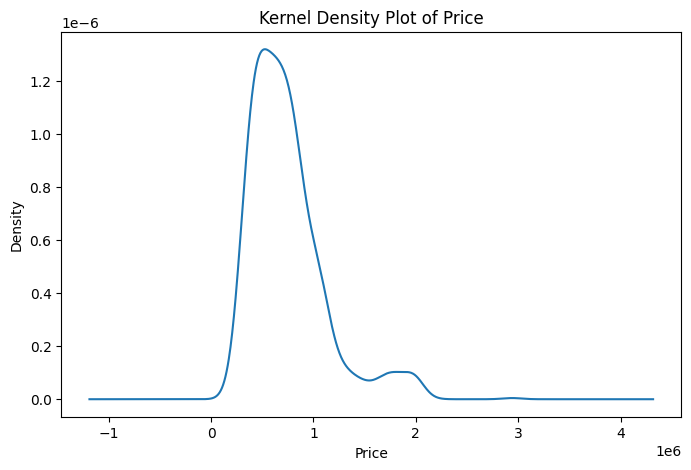

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cars_hw.csv")

print(df["Price"].describe())

plt.figure(figsize=(8,5))
df["Price"].plot(kind="density")
plt.title("Kernel Density Plot of Price")
plt.xlabel("Price")
plt.show()

body_summary = df.groupby("Body_Type")["Price"].describe()
print(body_summary)

The Price variable has a mean of about 741,020 rupees and a median of 666,500 rupees, indicating slight right skewness. The kernel density plot confirms this, showing most cars clustered in the mid-price range with a long right tail due to a smaller number of high-priced vehicles. The large standard deviation (367,323 rupees) indicates substantial variability in prices.

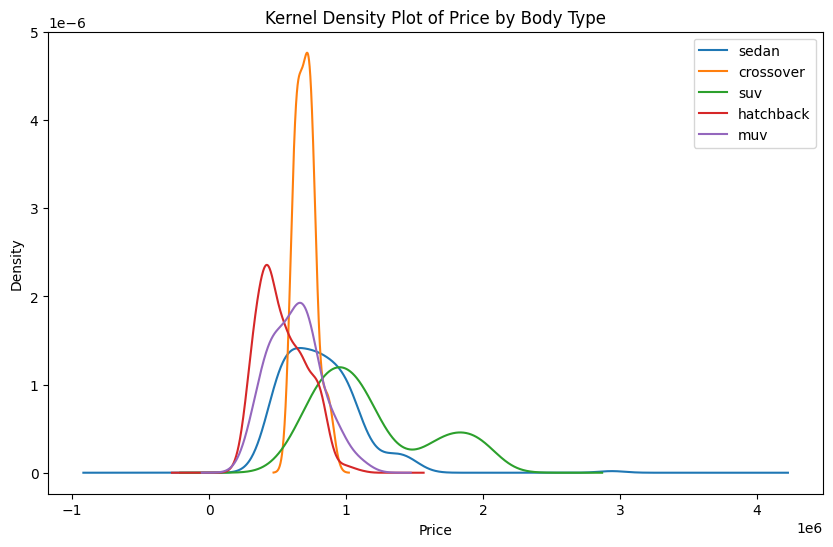

In [12]:
plt.figure(figsize=(10,6))
for b in df["Body_Type"].unique():
    df.loc[df["Body_Type"] == b, "Price"].plot(kind="density", label=b)

plt.title("Kernel Density Plot of Price by Body Type")
plt.xlabel("Price")
plt.legend()
plt.show()

The grouped density plot shows that SUVs have the highest prices and the greatest variability, as their distribution is shifted furthest to the right and is the widest. Sedans are also relatively expensive, while hatchbacks are the least expensive and most concentrated. Crossovers show a narrow distribution, indicating lower variance, and MUVs fall in between.

In [13]:
import statsmodels.formula.api as smf

model1 = smf.ols("Price ~ Seating_Capacity", data=df).fit()
print(model1.summary())
print(model1.params)

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0245
Time:                        03:44:30   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

When regressing Price on Seating_Capacity as a numeric variable, the slope coefficient is approximately 59,268. This means that each additional seat is associated with an estimated increase of about 59,268 rupees in price, on average. However, the R-squared value is very low (0.005), indicating that seating capacity alone explains very little of the variation in car prices.

In [14]:
model2 = smf.ols("Price ~ C(Seating_Capacity)", data=df).fit()
print(model2.summary())
print(model2.params)

print(df.groupby("Seating_Capacity")["Price"].mean())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000267
Time:                        03:45:05   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

When Seating_Capacity is treated as a categorical variable, the mean prices do not increase steadily with the number of seats. Prices rise from 4 to 6 seats, but then decrease for 7 and 8 seats, indicating a non-linear pattern. Therefore, the differences in price are not roughly linear in seating capacity. Some of this irregularity is likely due to very small sample sizes in certain categories (such as 4 and 6 seats), which makes those averages less reliable.

In [15]:
df["Age"] = 2023 - df["Make_Year"]

In [16]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = df[["Age"]]
y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=42)

rmse_results = {}

for d in range(1, 11):
    pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("model", LinearRegression())
    ])
    rmse = np.sqrt(-cross_val_score(
        pipe, X, y, cv=kf, scoring="neg_mean_squared_error"
    )).mean()
    rmse_results[d] = rmse

print(rmse_results)
best_degree = min(rmse_results, key=rmse_results.get)
print("Best degree:", best_degree)

{1: np.float64(310765.36071398546), 2: np.float64(310779.2959641378), 3: np.float64(309697.34463849204), 4: np.float64(308871.56777747674), 5: np.float64(307368.9819501825), 6: np.float64(307522.5236335561), 7: np.float64(306433.41895812505), 8: np.float64(304974.9269379318), 9: np.float64(304139.397735247), 10: np.float64(304451.46767464094)}
Best degree: 9


I created a new variable for Age by subtracting Make_Year from the current year and then used 10-fold cross-validation to compare polynomial models of Price on Age with degrees 1 through 10. The RMSE decreased as the degree increased, with the lowest value occurring at degree 9 (RMSE ≈ 304,139). Therefore, the optimal model includes 9 powers of Age. This indicates that the relationship between Age and Price is nonlinear, although the improvements in fit become smaller at higher degrees.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


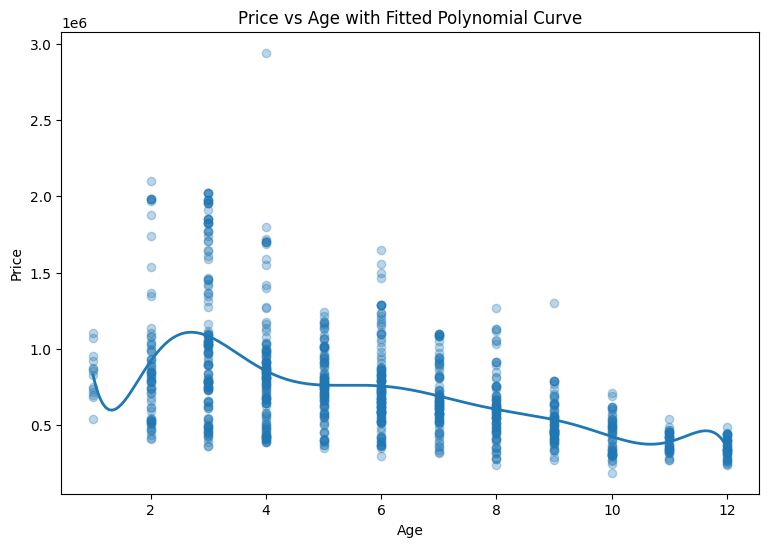

In [17]:
best_degree = 9

pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("model", LinearRegression())
])

pipe.fit(X, y)

age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 200).reshape(-1, 1)
pred_price = pipe.predict(age_grid)

plt.figure(figsize=(9,6))
plt.scatter(df["Age"], df["Price"], alpha=0.3)
plt.plot(age_grid, pred_price, linewidth=2)
plt.title("Price vs Age with Fitted Polynomial Curve")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

The scatterplot shows that price generally decreases as age increases, which is consistent with expectations for used cars. The fitted polynomial curve captures this overall downward trend, although it shows some fluctuations at lower ages. While the model fits the general pattern reasonably well, it does not fully capture the variability in the data, as prices vary widely for cars of the same age. Additionally, the curve shows some irregularity, suggesting slight overfitting due to the high polynomial degree. Overall, the model captures the main trend but does not perfectly fit the data.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [18]:
import pandas as pd

df = pd.read_csv("heart_hw.csv")

df = df[["y", "age", "transplant"]]

survival_rates = df.groupby("transplant")["y"].mean()
print(survival_rates)

ate = survival_rates["treatment"] - survival_rates["control"]
print("ATE:", ate)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
ATE: 0.23017902813299232


The proportion of individuals who survive three years is 0.1176 in the control group and 0.3478 in the treatment group. The average treatment effect (ATE) is therefore:

ATE = 0.3478 − 0.1176 = 0.2302

This means that receiving a heart transplant is associated with about a 23.0 percentage point increase in the probability of surviving three years.

In [19]:
import statsmodels.formula.api as smf

model1 = smf.ols("y ~ C(transplant)", data=df).fit()
print(model1.summary())
print(model1.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0133
Time:                        03:55:19   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

When regressing survival on transplant status, the intercept is 0.1176 and the treatment coefficient is 0.2302. These exactly match the survival rate in the control group and the average treatment effect computed in part 1. The intercept represents the probability of survival for individuals in the control group, while the treatment coefficient represents the increase in survival probability associated with receiving a transplant.

In [20]:
model2 = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(model2.summary())
print(model2.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000357
Time:                        03:55:36   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

When age is added to the regression, the transplant coefficient increases from 0.2302 to 0.2647. This means that after controlling for age, receiving a transplant is associated with about a 26.5 percentage point increase in the probability of surviving three years. The age coefficient is -0.0136, meaning that each additional year of age is associated with about a 1.36 percentage point decrease in survival probability, holding transplant status constant. The intercept represents the predicted survival probability for a control individual at age 0, which is not meaningful in practice. Because this model assumes a constant treatment effect across ages, the raw ATE from part 1 underestimates the effect of transplant for all ages.

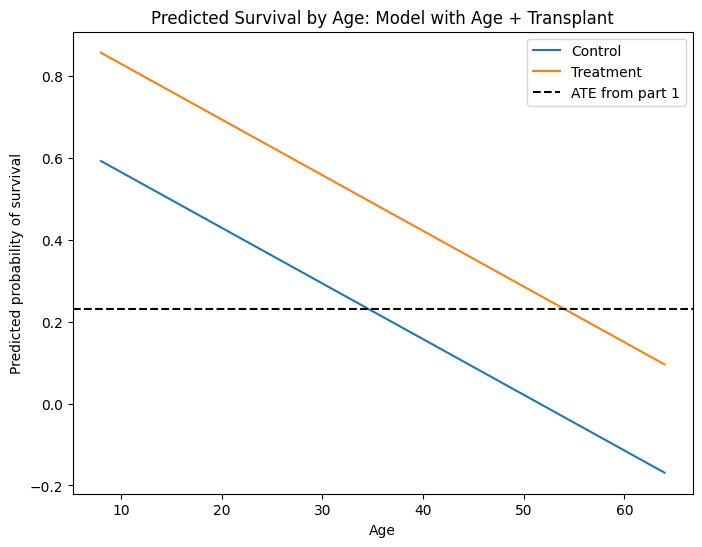

In [21]:
import numpy as np
import matplotlib.pyplot as plt

age_grid = np.linspace(df["age"].min(), df["age"].max(), 200)

pred_control = model2.params["Intercept"] + model2.params["age"] * age_grid
pred_treat = (
    model2.params["Intercept"]
    + model2.params["C(transplant)[T.treatment]"]
    + model2.params["age"] * age_grid
)

ate = 0.230179

plt.figure(figsize=(8,6))
plt.plot(age_grid, pred_control, label="Control")
plt.plot(age_grid, pred_treat, label="Treatment")
plt.axhline(ate, linestyle="--", color="black", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Predicted Survival by Age: Model with Age + Transplant")
plt.legend()
plt.show()

The plot shows that the predicted treatment and control lines are parallel, meaning the treatment effect is constant across age in this model. The vertical distance between the lines is about 0.2647, which is larger than the ATE from part 1 (0.2302). Therefore, the ATE underestimates the effect of a transplant at all ages and does not overestimate it for any age.

In [22]:
model3 = smf.ols("y ~ C(transplant) * age", data=df).fit()
print(model3.summary())
print(model3.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000310
Time:                        03:57:31   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

When transplant, age, and their interaction are included in the model, the treatment effect becomes age-dependent. The estimated effect of a transplant is 0.9078 − 0.0146 × age, which means that the benefit of a transplant decreases as age increases. This indicates that younger patients benefit more from a transplant than older patients. Comparing this to the average treatment effect from part 1 (0.2302), the ATE underestimates the effect of a transplant for younger individuals and overestimates the effect for older individuals. The crossover occurs at approximately age 46, where the age-specific treatment effect equals the ATE. This demonstrates that allowing age and transplant to interact reveals important heterogeneity in treatment effects that is not captured by a constant ATE.

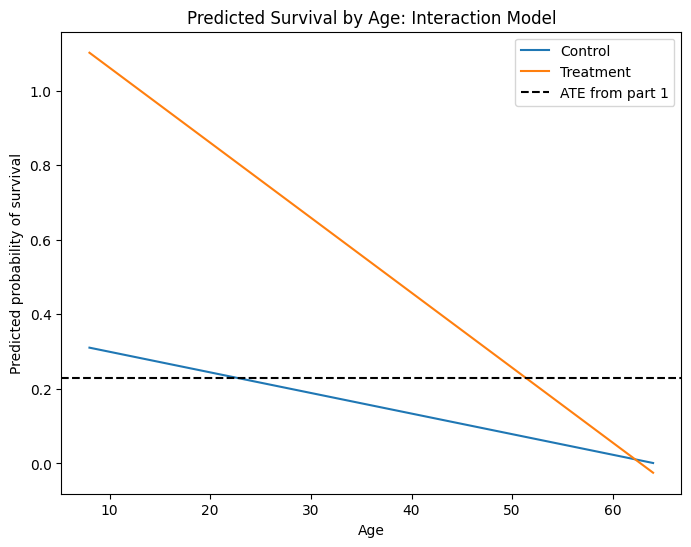

In [23]:
pred_control_int = model3.params["Intercept"] + model3.params["age"] * age_grid
pred_treat_int = (
    model3.params["Intercept"]
    + model3.params["C(transplant)[T.treatment]"]
    + (model3.params["age"] + model3.params["C(transplant)[T.treatment]:age"]) * age_grid
)

plt.figure(figsize=(8,6))
plt.plot(age_grid, pred_control_int, label="Control")
plt.plot(age_grid, pred_treat_int, label="Treatment")
plt.axhline(ate, linestyle="--", color="black", label="ATE from part 1")
plt.xlabel("Age")
plt.ylabel("Predicted probability of survival")
plt.title("Predicted Survival by Age: Interaction Model")
plt.legend()
plt.show()

The interaction model shows that the predicted survival lines for treatment and control are no longer parallel, meaning the treatment effect varies with age. The gap between the treatment and control groups is larger at younger ages and decreases as age increases. This indicates that the benefit of a transplant is greater for younger patients and declines with age. Comparing this to the constant ATE from part 1, the ATE underestimates the treatment effect for younger individuals and overestimates it for older individuals. The crossover occurs at approximately age 46, where the model-predicted treatment effect equals the ATE. This demonstrates that allowing age and transplant to interact reveals important variation in treatment effects across different ages.

In [24]:
cross_age = (0.907751 - 0.230179) / 0.014591
print(cross_age)

46.43766705503392


The interaction model shows that the treatment effect depends on age and is given by 0.9078 − 0.0146 × age. This implies that the benefit of a transplant decreases as age increases. Solving for when this effect equals the average treatment effect (0.2302) gives a crossover age of approximately 46.4. For individuals younger than this age, the ATE underestimates the effect of a transplant, while for individuals older than this age, the ATE overestimates the effect. This demonstrates that the treatment effect varies substantially across ages and is not well captured by a single average value.

In [25]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

X1 = pd.get_dummies(df[["transplant"]], drop_first=True)

X2 = X1.copy()
X2["age"] = df["age"]

X3 = X2.copy()
X3["transplant_treatment:age"] = X1.iloc[:, 0] * df["age"]

y = df["y"]

kf = KFold(n_splits=10, shuffle=True, random_state=42)

rmse1 = np.sqrt(-cross_val_score(
    LinearRegression(), X1, y, cv=kf, scoring="neg_mean_squared_error"
)).mean()

rmse2 = np.sqrt(-cross_val_score(
    LinearRegression(), X2, y, cv=kf, scoring="neg_mean_squared_error"
)).mean()

rmse3 = np.sqrt(-cross_val_score(
    LinearRegression(), X3, y, cv=kf, scoring="neg_mean_squared_error"
)).mean()

print("RMSE Model 1:", rmse1)
print("RMSE Model 2:", rmse2)
print("RMSE Model 3:", rmse3)

RMSE Model 1: 0.43651009364500126
RMSE Model 2: 0.416697053853562
RMSE Model 3: 0.41295572153919125


Using 10-fold cross validation, the RMSE is 0.4365 for the model with transplant alone, 0.4167 for the model with transplant and age, and 0.4130 for the interaction model. The interaction model performs best, indicating that allowing the effect of transplant to vary by age improves predictive accuracy. However, the improvement over the model with age and transplant is relatively small, suggesting that most of the predictive power comes from including age rather than the interaction term.

There are several concerns about using this model to prioritize transplant access. First, the data are observational rather than from a randomized experiment, so the estimated treatment effects may be biased due to confounding factors such as patient health status or access to care. Second, the model is very simple and only includes age and transplant status, omitting many important clinical variables that affect survival. Third, the interaction model suggests that younger patients benefit more from transplants, but using this directly in decision-making could raise ethical concerns by systematically disadvantaging older patients. Finally, the linear probability model can produce predicted probabilities outside the valid range of 0 to 1, which is another limitation for modeling survival outcomes.